# RNN-LSTM — Ventana de entrada 5 · Salida 1

Notebook de búsqueda de hiperparámetros para la combinación `(input=5, output=1)`, siguiendo la misma metodología de dos etapas que `rnn-lstm.ipynb`.

- **Entrada**: secuencia de 5 pasos temporales, 23 features (retornos por ticker).
- **Salida**: 23 valores — media de retornos en la ventana de salida de 1 día (siguiente día).
- **Pérdida**: MAE.

**Adaptaciones del grid respecto al notebook de referencia (input=30, output=5):**
- `units ∈ {16, 32, 64}` en lugar de `{32, 64, 128}`: con solo 5 pasos temporales, estados ocultos grandes generan capacidad sin información temporal suficiente para aprovecharla.
- `lstm_layers ∈ {1, 2}` y `dropout ∈ {0.0, 0.2}`: sin cambios — la profundidad y la regularización siguen siendo ejes relevantes incluso con secuencias cortas.
- Grid de entrenamiento (`lr`, `batch_size`): idéntico al notebook de referencia.

In [1]:
import sys
import mlflow
from pathlib import Path

# model/rnn/lstm/ -> tres niveles hasta la raíz del proyecto
_here = Path.cwd()
PROJECT_ROOT = next(
    p for p in [_here, _here.parent, _here.parent.parent, _here.parent.parent.parent]
    if (p / 'util.py').exists()
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

mlflow.set_tracking_uri(f"sqlite:///{PROJECT_ROOT / 'model' / 'mlflow.db'}")

EXPERIMENT_NAME = "Red_Neuronal_Recurrente_LSTM"
mlflow.set_experiment(EXPERIMENT_NAME)

import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import keras
from keras.models import Sequential
from keras.layers import LSTM, Dense, Input, Dropout
from keras.callbacks import EarlyStopping
from keras.optimizers import Adam

from sklearn.metrics import mean_absolute_error

from util import get_train_test, RANDOM_SEED, plot_training_curve, load_benchmark

np.random.seed(RANDOM_SEED)
keras.utils.set_random_seed(RANDOM_SEED)

/opt/homebrew/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Carga de datos

Igual que en el notebook de referencia: tensor 3D `[samples, timesteps, features]` con el 10% final del train como validación.

In [2]:
def load_seq_data(input_window_size, output_window_size):
    """Devuelve datos con shape 3D [samples, timesteps, features] para LSTM."""
    d = get_train_test(input_window_size=input_window_size, output_window_size=output_window_size)

    X_train = d.X_train
    X_test  = d.X_test
    y_train = d.y_train
    y_test  = d.y_test

    val_size = int(0.10 * X_train.shape[0])
    X_val   = X_train[-val_size:]
    y_val   = y_train[-val_size:]
    X_train = X_train[:-val_size]
    y_train = y_train[:-val_size]

    return X_train, y_train, X_val, y_val, X_test, y_test


INPUT_W, OUTPUT_W = 5, 1

X_train_seq, y_train_seq, X_val_seq, y_val_seq, X_test_seq, y_test_seq = load_seq_data(
    INPUT_W, OUTPUT_W
)

print(f"Ventana: input={INPUT_W}, output={OUTPUT_W}")
print(f"X_train_seq: {X_train_seq.shape}  -> (samples, timesteps, features)")
print(f"y_train_seq: {y_train_seq.shape}")
print(f"X_val_seq:   {X_val_seq.shape}")
print(f"y_val_seq:   {y_val_seq.shape}")
print(f"X_test_seq:  {X_test_seq.shape}")
print(f"y_test_seq:  {y_test_seq.shape}")

Ventana: input=5, output=1
X_train_seq: (13106, 5, 23)  -> (samples, timesteps, features)
y_train_seq: (13106, 23)
X_val_seq:   (1456, 5, 23)
y_val_seq:   (1456, 23)
X_test_seq:  (1618, 5, 23)
y_test_seq:  (1618, 23)


## Modelo base

LSTM de una capa con 64 unidades, sin dropout, como referencia antes de la búsqueda.

In [3]:
num_units = 64

model_base = Sequential()
model_base.add(Input(shape=(X_train_seq.shape[1], X_train_seq.shape[2])))
model_base.add(LSTM(num_units, return_sequences=False))
model_base.add(Dense(y_train_seq.shape[1]))

model_base.compile(loss="mean_absolute_error", optimizer="Adam")
model_base.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        22,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 23)             │         1,495 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,023 (93.84 KB)

 Trainable params: 24,023 (93.84 KB)

 Non-trainable params: 0 (0.00 B)

## Entrenamiento del modelo base

In [4]:
batch_size_base = 128
es_base = EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True)

hist_base = model_base.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=500,
    batch_size=batch_size_base,
    callbacks=[es_base],
)

Epoch 1/500
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0120 - val_loss: 0.0091
Epoch 2/500
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0119 - val_loss: 0.0091
Epoch 3/500
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0119 - val_loss: 0.0091
Epoch 4/500
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0119 - val_loss: 0.0091
Epoch 5/500
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0119 - val_loss: 0.0091
Epoch 6/500
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0119 - val_loss: 0.0091
Epoch 7/500
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0119 - val_loss: 0.0091
Epoch 8/500
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0118 - val_loss: 0.0091
Epoch 9/500
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0118 - val_loss: 0.0091
Epoch 10/500
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0118 - val_loss: 0.0091
Epoch 11/500
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0118 - val_loss: 0.0091
Epoch 12/500
103/103 ━━━━━━━━━━━━━━━━━━━━

## Curva de pérdida — modelo base

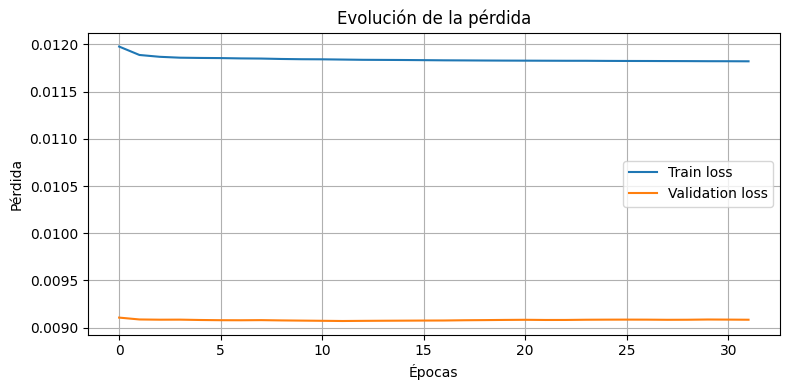

In [5]:
fig_base = plot_training_curve(hist_base, show=True)

## Evaluación del modelo base (MAE train, val y test)

In [6]:
run_name_base = f"{EXPERIMENT_NAME}_input{INPUT_W}_output{OUTPUT_W}_base"
existing = mlflow.search_runs(filter_string=f'tags.mlflow.runName = "{run_name_base}"')
if not existing.empty:
    mlflow.delete_run(existing.iloc[0].run_id)

with mlflow.start_run(run_name=run_name_base):
    y_pred_train = model_base.predict(X_train_seq, verbose=0)
    y_pred_val   = model_base.predict(X_val_seq,   verbose=0)
    y_pred_test  = model_base.predict(X_test_seq,  verbose=0)

    mae_train_base = mean_absolute_error(y_train_seq, y_pred_train)
    mae_val_base   = mean_absolute_error(y_val_seq,   y_pred_val)
    mae_test_base  = mean_absolute_error(y_test_seq,  y_pred_test)

    for epoch, (tl, vl) in enumerate(zip(hist_base.history["loss"], hist_base.history["val_loss"])):
        mlflow.log_metric("train_loss", tl, step=epoch)
        mlflow.log_metric("val_loss",   vl, step=epoch)

    mlflow.log_figure(fig_base, "plots/loss_curve.png")
    plt.close(fig_base)

    mlflow.log_param("model_type",         "LSTM")
    mlflow.log_param("lstm_units",         num_units)
    mlflow.log_param("input_window_size",  INPUT_W)
    mlflow.log_param("output_window_size", OUTPUT_W)
    mlflow.log_param("num_features",       X_train_seq.shape[2])
    mlflow.log_param("num_samples",        X_train_seq.shape[0])
    mlflow.log_param("n_params",           model_base.count_params())
    mlflow.log_param("epochs",             len(hist_base.history["loss"]))
    mlflow.log_param("batch_size",         batch_size_base)

    mlflow.log_metric("train_mae", mae_train_base)
    mlflow.log_metric("val_mae",   mae_val_base)
    mlflow.log_metric("test_mae",  mae_test_base)

    mlflow.keras.log_model(model_base, name="lstm_model")

    print(f"MAE train: {mae_train_base:.6f}")
    print(f"MAE val:   {mae_val_base:.6f}")
    print(f"MAE test:  {mae_test_base:.6f}")

2026/05/01 17:12:12 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


MAE train: 0.011816
MAE val:   0.009071
MAE test:  0.012278


## Búsqueda de hiperparámetros

Misma metodología que en el notebook de referencia: dos etapas secuenciales sobre la ventana fija `(input=5, output=1)`.

1. **Arquitectura**: `lstm_layers × units × dropout`. El ganador se fija para la etapa 2.
2. **Entrenamiento**: `learning_rate × batch_size`, con la arquitectura ganadora.

**Grid adaptado para input=5, output=1:**
- `units ∈ {16, 32, 64}` — con solo 5 pasos temporales, 128 unidades introduce capacidad que la secuencia no puede aprovechar; se elimina ese rango.
- Todo lo demás: igual que en el notebook de referencia.

Selección por **MAE de validación**. Test intacto hasta el retrain final.

In [7]:
X_tr, y_tr, X_val, y_val, X_te, y_te = load_seq_data(INPUT_W, OUTPUT_W)

print(f"X_tr:  {X_tr.shape}   y_tr:  {y_tr.shape}")
print(f"X_val: {X_val.shape}  y_val: {y_val.shape}")
print(f"X_te:  {X_te.shape}   y_te:  {y_te.shape}")


def build_lstm(lstm_layers: int, units: int, dropout: float, lr: float = 1e-3):
    keras.utils.set_random_seed(RANDOM_SEED)
    m = Sequential()
    m.add(Input(shape=(X_tr.shape[1], X_tr.shape[2])))
    for i in range(lstm_layers):
        return_seq = (i < lstm_layers - 1)
        m.add(LSTM(units, return_sequences=return_seq, dropout=dropout))
    m.add(Dense(y_tr.shape[1]))
    m.compile(loss="mean_absolute_error", optimizer=Adam(learning_rate=lr))
    return m


def fit_eval(model, batch_size: int = 128, epochs: int = 200, patience: int = 10, verbose: int = 0):
    es = EarlyStopping(monitor="val_loss", patience=patience, restore_best_weights=True)
    h = model.fit(X_tr, y_tr, validation_data=(X_val, y_val), epochs=epochs,
                  batch_size=batch_size, callbacks=[es], verbose=verbose)
    mae_tr  = mean_absolute_error(y_tr,  model.predict(X_tr,  verbose=0))
    mae_val = mean_absolute_error(y_val, model.predict(X_val, verbose=0))
    mae_te  = mean_absolute_error(y_te,  model.predict(X_te,  verbose=0))
    return mae_tr, mae_val, mae_te, h

X_tr:  (13106, 5, 23)   y_tr:  (13106, 23)
X_val: (1456, 5, 23)  y_val: (1456, 23)
X_te:  (1618, 5, 23)   y_te:  (1618, 23)


### Etapa 1 — arquitectura

12 combinaciones: `lstm_layers ∈ {1, 2}` · `units ∈ {16, 32, 64}` · `dropout ∈ {0.0, 0.2}`. Adam lr=1e-3, batch=128.

In [8]:
arch_grid = list(itertools.product([1, 2], [16, 32, 64], [0.0, 0.2]))

results_arch = []
batch_size_arch = 128

for ll, u, dr in arch_grid:
    run_name = f"{EXPERIMENT_NAME}_arch_layers{ll}_units{u}_drop{dr}_input{INPUT_W}_output{OUTPUT_W}"
    existing = mlflow.search_runs(filter_string=f'tags.mlflow.runName = "{run_name}"')
    if not existing.empty:
        mlflow.delete_run(existing.iloc[0].run_id)

    with mlflow.start_run(run_name=run_name):
        model = build_lstm(ll, u, dr, lr=1e-3)
        mae_tr, mae_val, mae_te, h = fit_eval(model, batch_size=batch_size_arch)

        for epoch, (tl, vl) in enumerate(zip(h.history["loss"], h.history["val_loss"])):
            mlflow.log_metric("train_loss", tl, step=epoch)
            mlflow.log_metric("val_loss",   vl, step=epoch)

        fig = plot_training_curve(h)
        mlflow.log_figure(fig, "plots/loss_curve.png")
        plt.close(fig)

        mlflow.log_param("model_type",         "LSTM")
        mlflow.log_param("lstm_layers",        ll)
        mlflow.log_param("units",              u)
        mlflow.log_param("dropout",            dr)
        mlflow.log_param("learning_rate",      1e-3)
        mlflow.log_param("batch_size",         batch_size_arch)
        mlflow.log_param("input_window_size",  INPUT_W)
        mlflow.log_param("output_window_size", OUTPUT_W)
        mlflow.log_param("num_features",       X_tr.shape[2])
        mlflow.log_param("n_params",           model.count_params())
        mlflow.log_param("epochs",             len(h.history["loss"]))

        mlflow.log_metric("train_mae", mae_tr)
        mlflow.log_metric("val_mae",   mae_val)
        mlflow.log_metric("test_mae",  mae_te)

        mlflow.keras.log_model(model, name="lstm_model")

        results_arch.append({
            "lstm_layers": ll, "units": u, "dropout": dr,
            "MAE_train": mae_tr, "MAE_val": mae_val, "MAE_test": mae_te,
            "epochs": len(h.history["loss"]), "n_params": model.count_params(),
        })
        print(f"layers={ll} units={u:>3} dropout={dr}  ->  MAE val={mae_val:.6f} | train={mae_tr:.6f} | test={mae_te:.6f} | epochs={len(h.history['loss']):>3}")

results_arch_df = pd.DataFrame(results_arch).sort_values("MAE_val").reset_index(drop=True)
results_arch_df.head(10)

2026/05/01 17:12:46 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


layers=1 units= 16 dropout=0.0  ->  MAE val=0.009062 | train=0.011838 | test=0.012249 | epochs= 18


2026/05/01 17:12:52 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


layers=1 units= 16 dropout=0.2  ->  MAE val=0.009052 | train=0.011836 | test=0.012241 | epochs= 20


2026/05/01 17:12:57 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


...

2026/05/01 17:13:56 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


layers=2 units= 64 dropout=0.0  ->  MAE val=0.009054 | train=0.011845 | test=0.012246 | epochs= 15


2026/05/01 17:14:07 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


layers=2 units= 64 dropout=0.2  ->  MAE val=0.009052 | train=0.011838 | test=0.012244 | epochs= 23


,lstm_layers,units,dropout,MAE_train,MAE_val,MAE_test,epochs,n_params
0,2,16,0.2,0.011851,0.009039,0.012236,15,5063
1,2,16,0.0,0.011855,0.009044,0.012243,16,5063
2,2,32,0.2,0.011857,0.009044,0.012237,17,16247
3,2,32,0.0,0.011847,0.009050,0.012242,18,16247
4,2,64,0.2,0.011838,0.009052,0.012244,23,57047
5,1,16,0.2,0.011836,0.009052,0.012241,20,2951
6,2,64,0.0,0.011845,0.009054,0.012246,15,57047
7,1,32,0.2,0.011845,0.009058,0.012251,14,7927
8,1,64,0.2,0.011816,0.009061,0.012270,26,24023
9,1,16,0.0,0.011838,0.009062,0.012249,18,2951


### Etapa 2 — entrenamiento

Arquitectura ganadora de la etapa 1. Barrido de `learning_rate ∈ {1e-2, 1e-3, 1e-4}` · `batch_size ∈ {64, 128, 256}`.

In [9]:
best_arch = results_arch_df.iloc[0]
print(f"Mejor arquitectura: layers={int(best_arch.lstm_layers)}  units={int(best_arch.units)}  dropout={best_arch.dropout}")
print(f"  MAE val = {best_arch.MAE_val:.6f}")

train_grid = list(itertools.product([1e-2, 1e-3, 1e-4], [64, 128, 256]))

results_train = []
for lr, bs in train_grid:
    run_name = f"{EXPERIMENT_NAME}_train_lr{lr:.0e}_batch{bs}_input{INPUT_W}_output{OUTPUT_W}"
    existing = mlflow.search_runs(filter_string=f'tags.mlflow.runName = "{run_name}"')
    if not existing.empty:
        mlflow.delete_run(existing.iloc[0].run_id)

    with mlflow.start_run(run_name=run_name):
        model = build_lstm(int(best_arch.lstm_layers), int(best_arch.units),
                           float(best_arch.dropout), lr=lr)
        mae_tr, mae_val, mae_te, h = fit_eval(model, batch_size=bs)

        for epoch, (tl, vl) in enumerate(zip(h.history["loss"], h.history["val_loss"])):
            mlflow.log_metric("train_loss", tl, step=epoch)
            mlflow.log_metric("val_loss",   vl, step=epoch)

        fig = plot_training_curve(h)
        mlflow.log_figure(fig, "plots/loss_curve.png")
        plt.close(fig)

        mlflow.log_param("model_type",         "LSTM")
        mlflow.log_param("lstm_layers",        int(best_arch.lstm_layers))
        mlflow.log_param("units",              int(best_arch.units))
        mlflow.log_param("dropout",            float(best_arch.dropout))
        mlflow.log_param("learning_rate",      lr)
        mlflow.log_param("batch_size",         bs)
        mlflow.log_param("input_window_size",  INPUT_W)
        mlflow.log_param("output_window_size", OUTPUT_W)
        mlflow.log_param("num_features",       X_tr.shape[2])
        mlflow.log_param("n_params",           model.count_params())
        mlflow.log_param("epochs",             len(h.history["loss"]))

        mlflow.log_metric("train_mae", mae_tr)
        mlflow.log_metric("val_mae",   mae_val)
        mlflow.log_metric("test_mae",  mae_te)

        mlflow.keras.log_model(model, name="lstm_model")

        results_train.append({
            "learning_rate": lr, "batch_size": bs,
            "MAE_train": mae_tr, "MAE_val": mae_val, "MAE_test": mae_te,
            "epochs": len(h.history["loss"]),
        })
        print(f"lr={lr:.0e} batch={bs:>3}  ->  MAE val={mae_val:.6f} | train={mae_tr:.6f} | test={mae_te:.6f} | epochs={len(h.history['loss']):>3}")

results_train_df = pd.DataFrame(results_train).sort_values("MAE_val").reset_index(drop=True)
results_train_df

Mejor arquitectura: layers=2  units=16  dropout=0.2
  MAE val = 0.009039


2026/05/01 17:14:36 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


lr=1e-02 batch= 64  ->  MAE val=0.009311 | train=0.012131 | test=0.012466 | epochs= 19


2026/05/01 17:14:43 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


lr=1e-02 batch=128  ->  MAE val=0.009195 | train=0.012006 | test=0.012337 | epochs= 11


...

2026/05/01 17:15:30 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


lr=1e-04 batch=128  ->  MAE val=0.009037 | train=0.011846 | test=0.012243 | epochs= 25


2026/05/01 17:15:38 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


lr=1e-04 batch=256  ->  MAE val=0.009035 | train=0.011844 | test=0.012238 | epochs= 35


,learning_rate,batch_size,MAE_train,MAE_val,MAE_test,epochs
0,0.0001,256,0.011844,0.009035,0.012238,35
1,0.0001,128,0.011846,0.009037,0.012243,25
2,0.0001,64,0.011836,0.009038,0.012240,27
3,0.0010,128,0.011851,0.009039,0.012236,15
4,0.0010,64,0.011861,0.009042,0.012240,22
5,0.0010,256,0.011844,0.009043,0.012238,24
6,0.0100,256,0.011965,0.009108,0.012290,13
7,0.0100,128,0.012006,0.009195,0.012337,11
8,0.0100,64,0.012131,0.009311,0.012466,19


### Retrain y evaluación final en test

Con los HPs ganadores de ambas etapas entrenamos el modelo definitivo y evaluamos en test por primera vez. Comparamos contra la LSTM base y contra la regresión lineal para `(input=5, output=1)`.

In [10]:
best_train = results_train_df.iloc[0]
print("Configuración ganadora:")
print(f"  lstm_layers   = {int(best_arch.lstm_layers)}")
print(f"  units         = {int(best_arch.units)}")
print(f"  dropout       = {float(best_arch.dropout)}")
print(f"  learning_rate = {best_train.learning_rate:.0e}")
print(f"  batch_size    = {int(best_train.batch_size)}")

best_model = build_lstm(
    int(best_arch.lstm_layers),
    int(best_arch.units),
    float(best_arch.dropout),
    lr=float(best_train.learning_rate),
)
mae_tr_best, mae_val_best, mae_te_best, hist_best = fit_eval(
    best_model, batch_size=int(best_train.batch_size)
)

linreg_bench = load_benchmark("lr_benchmark")
linreg_row   = linreg_bench[
    (linreg_bench.input_window == INPUT_W) & (linreg_bench.output_window == OUTPUT_W)
].iloc[0]

run_name_tuned = f"{EXPERIMENT_NAME}_tuned_input{INPUT_W}_output{OUTPUT_W}"
existing = mlflow.search_runs(filter_string=f'tags.mlflow.runName = "{run_name_tuned}"')
if not existing.empty:
    mlflow.delete_run(existing.iloc[0].run_id)

with mlflow.start_run(run_name=run_name_tuned):
    for epoch, (tl, vl) in enumerate(zip(hist_best.history["loss"], hist_best.history["val_loss"])):
        mlflow.log_metric("train_loss", tl, step=epoch)
        mlflow.log_metric("val_loss",   vl, step=epoch)

    fig_best = plot_training_curve(hist_best)
    mlflow.log_figure(fig_best, "plots/loss_curve.png")
    plt.close(fig_best)

    mlflow.log_param("model_type",         "LSTM")
    mlflow.log_param("lstm_layers",        int(best_arch.lstm_layers))
    mlflow.log_param("units",              int(best_arch.units))
    mlflow.log_param("dropout",            float(best_arch.dropout))
    mlflow.log_param("learning_rate",      float(best_train.learning_rate))
    mlflow.log_param("batch_size",         int(best_train.batch_size))
    mlflow.log_param("input_window_size",  INPUT_W)
    mlflow.log_param("output_window_size", OUTPUT_W)
    mlflow.log_param("n_params",           best_model.count_params())
    mlflow.log_param("epochs",             len(hist_best.history["loss"]))
    mlflow.log_metric("train_mae",         mae_tr_best)
    mlflow.log_metric("val_mae",           mae_val_best)
    mlflow.log_metric("test_mae",          mae_te_best)
    mlflow.keras.log_model(best_model, name="lstm_model")

summary = pd.DataFrame([
    {"modelo": "Regresión lineal", "MAE_train": linreg_row.MAE_train, "MAE_test": linreg_row.MAE_test},
    {"modelo": "LSTM base",        "MAE_train": mae_train_base,       "MAE_test": mae_test_base},
    {"modelo": "LSTM tuneada",     "MAE_train": mae_tr_best,          "MAE_test": mae_te_best},
])
summary["Δ vs lin.reg."] = summary["MAE_test"] - linreg_row.MAE_test
summary

Configuración ganadora:
  lstm_layers   = 2
  units         = 16
  dropout       = 0.2
  learning_rate = 1e-04
  batch_size    = 256


2026/05/01 17:16:17 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


,modelo,MAE_train,MAE_test,Δ vs lin.reg.
0,Regresión lineal,0.011821,0.012384,0.000000
1,LSTM base,0.011816,0.012278,-0.000106
2,LSTM tuneada,0.011844,0.012238,-0.000146


### Visualización — top-10 configuraciones

MAE_val (barras azules) vs MAE_train (barras grises) para las mejores configuraciones de cada etapa.

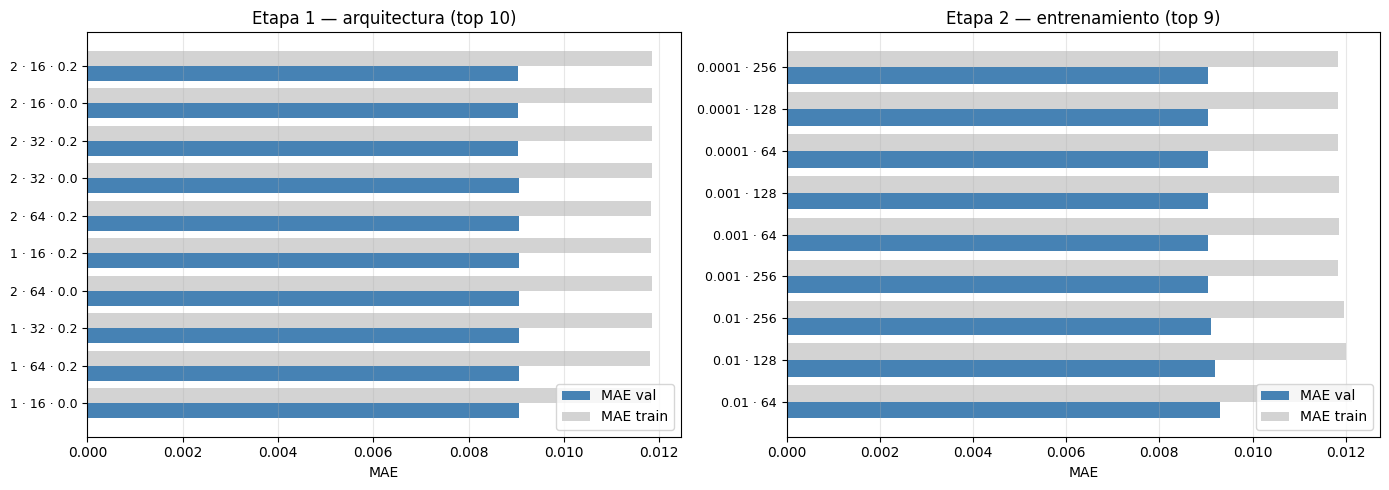

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

def plot_top(ax, df, label_cols, title, top=10):
    top_df = df.head(top).iloc[::-1]
    labels = top_df[label_cols].astype(str).agg(" · ".join, axis=1)
    ypos = np.arange(len(top_df))
    ax.barh(ypos - 0.2, top_df["MAE_val"],   height=0.4, label="MAE val",   color="steelblue")
    ax.barh(ypos + 0.2, top_df["MAE_train"], height=0.4, label="MAE train", color="lightgray")
    ax.set_yticks(ypos); ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel("MAE"); ax.set_title(title)
    ax.legend(loc="lower right"); ax.grid(True, axis="x", alpha=0.3)

plot_top(axes[0], results_arch_df,  ["lstm_layers", "units", "dropout"],
         "Etapa 1 — arquitectura (top 10)")
plot_top(axes[1], results_train_df, ["learning_rate", "batch_size"],
         f"Etapa 2 — entrenamiento (top {min(10, len(results_train_df))})")

plt.tight_layout(); plt.show()